In [1]:
# Install required packages
!pip install -q torch-scatter torch-sparse torch-geometric scipy pandas matplotlib seaborn tqdm pyarrow fastparquet scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 36.6 MB/s eta 0:00:00


In [2]:
# Clone the repository and add src to sys.path
import os
import sys

REPO_ROOT = '/content/antenna-gnn'

if not os.path.exists(REPO_ROOT):
    !git clone https://github.com/asparagusD/antenna_gnn.git {REPO_ROOT}
else:
    !cd {REPO_ROOT} && git pull

if f'{REPO_ROOT}/src' not in sys.path:
    sys.path.insert(0, f'{REPO_ROOT}/src')

Cloning into '/content/antenna-gnn'...
remote: Enumerating objects: 303, done.
remote: Counting objects: 100% (303/303), done.
remote: Compressing objects: 100% (174/174), done.
remote: Total 303 (delta 158), reused 257 (delta 114), pack-reused 0 (from 0)
Receiving objects: 100% (303/303), 6.51 MiB | 10.35 MiB/s, done.
Resolving deltas: 100% (158/158), done.


In [3]:
# Mount Google Drive and set data paths
from google.colab import drive
import os

drive.mount('/content/drive')

DATA_ROOT = '/content/drive/MyDrive/antenna_gnn'
RAW_DATA = '/content/drive/MyDrive/antenna_dataset'

# Create necessary directories in DATA_ROOT
os.makedirs(f'{DATA_ROOT}/artifacts', exist_ok=True)
os.makedirs(f'{DATA_ROOT}/figures', exist_ok=True)

Mounted at /content/drive


---
## Cell A — Load and Reconcile

Load the ceiling model (`ceiling_fullpool.pt` == `gnn_finetuned_multiscale.pt`),
normalization stats, frequency axis, and splits. Run inference over the 1,496
**validation** graphs, de-normalize predictions, and build a tidy DataFrame.

Includes the normalization guard (identities only: y_raw present, y ≠ y_raw,
round-trip < 1e-3, raw max ≤ 0.01 dB).

Then prints the canonical metric definition block and computes metrics on
validation, alongside the Chunk 15 **test** reference values for context.

In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL A — Load and Reconcile
# ═══════════════════════════════════════════════════════════════════════════

import json
import shutil
import time
import glob as glob_mod
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from collections import defaultdict
from torch.utils.data import Dataset as TorchDataset
from torch_geometric.loader import DataLoader
from scipy.signal import find_peaks
from tqdm.notebook import tqdm
from model import AntennaGNN

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── FinetuneDataset — frozen — validated in Chunk 13 ──
class FinetuneDataset(TorchDataset):
    """Fine-tune graph dataset with mandatory z-score normalization at load.

    On-disk data.y is raw dB. This dataset z-scores y at load time using
    the 25x25 training-split s11_mean / s11_std, and preserves y_raw.
    evaluate() de-normalizes with the same statistics.

    Never pass s11_mean=None or s11_std=None.
    """

    def __init__(self, indices, processed_dir_base, s11_mean, s11_std):
        assert s11_mean is not None, 'FinetuneDataset requires s11_mean (got None)'
        assert s11_std is not None,  'FinetuneDataset requires s11_std (got None)'
        self.indices = indices
        self.processed_dir_base = processed_dir_base
        self.s11_mean = s11_mean   # (201,) tensor
        self.s11_std  = s11_std    # (201,) tensor

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        grid_size, local_idx = self.indices[idx]
        path = f'{self.processed_dir_base}/{grid_size}x{grid_size}/sample_{local_idx}.pt'
        data = torch.load(path, weights_only=False)

        # Preserve raw dB target, then z-score
        data.y_raw = data.y.clone()                              # (1, 201) raw dB
        data.y = (data.y - self.s11_mean) / (self.s11_std + 1e-8)  # (1, 201) normalized

        return data


# ── Frequency axis ──
freq_axis = np.linspace(1.0, 4.0, 201)

# ── Load statistics — CPU for Dataset, device for evaluate ──
s11_mean_np = np.load(f'{DATA_ROOT}/artifacts/s11_mean.npy')
s11_std_np  = np.load(f'{DATA_ROOT}/artifacts/s11_std.npy')
s11_mean_cpu = torch.tensor(s11_mean_np, dtype=torch.float32)
s11_std_cpu  = torch.tensor(s11_std_np,  dtype=torch.float32)
s11_mean_dev = s11_mean_cpu.to(device)
s11_std_dev  = s11_std_cpu.to(device)
assert s11_mean_cpu.shape == (201,) and s11_std_cpu.shape == (201,)

# ── Load splits ──
with open(f'{DATA_ROOT}/splits/finetune_val_indices.json') as f:
    val_indices = json.load(f)
with open(f'{DATA_ROOT}/splits/finetune_test_indices.json') as f:
    test_indices = json.load(f)
with open(f'{DATA_ROOT}/splits/finetune_pool_indices.json') as f:
    pool_indices = json.load(f)

print(f'Pool: {len(pool_indices)}, Val: {len(val_indices)}, Test: {len(test_indices)}')
assert len(val_indices) == 1496, f'Expected 1496 val indices, got {len(val_indices)}'

# ── Local disk caching (like chunk-7) ──
processed_dir = f'{DATA_ROOT}/data/processed_finetune'
STAGE_LOCALLY = True

if STAGE_LOCALLY:
    drive_dir = f'{DATA_ROOT}/data/processed_finetune'
    local_dir = '/content/processed_finetune'
    try:
        src_files = glob_mod.glob(f'{drive_dir}/**/sample_*.pt', recursive=True)
        n_src = len(src_files)
        assert n_src > 0, f'no sample_*.pt found under {drive_dir}'

        free_gb = shutil.disk_usage('/content').free / 1e9
        probe = src_files[:20]
        est_gb = (sum(os.path.getsize(p) for p in probe) / len(probe)) * n_src / 1e9
        print(f'{n_src} files on Drive, ~{est_gb:.1f} GB estimated, '
              f'{free_gb:.1f} GB free on /content')
        assert free_gb > est_gb * 1.5, 'not enough local disk — staying on Drive'

        t0 = time.time()

        if os.path.isdir(local_dir):
            n_have = len(glob_mod.glob(f'{local_dir}/**/sample_*.pt', recursive=True))
            if n_have == n_src:
                print(f'already staged ({n_have} files), reusing')
            else:
                print(f'incomplete stage ({n_have}/{n_src}), re-copying')
                shutil.rmtree(local_dir)
                os.makedirs(local_dir, exist_ok=True)
        else:
            os.makedirs(local_dir, exist_ok=True)

        for src_path in tqdm(src_files, desc='Staging dataset locally'):
            relative_path = os.path.relpath(src_path, drive_dir)
            dst_path = os.path.join(local_dir, relative_path)
            os.makedirs(os.path.dirname(dst_path), exist_ok=True)
            if not os.path.exists(dst_path):
                shutil.copy2(src_path, dst_path)

        n_dst = len(glob_mod.glob(f'{local_dir}/**/sample_*.pt', recursive=True))
        assert n_dst == n_src, f'staged {n_dst} of {n_src} files — incomplete'
        print(f'staged {n_dst} files in {time.time() - t0:.0f} s')

        processed_dir = local_dir
        print(f'processed_dir -> {processed_dir}')

    except Exception as e:
        print(f'staging skipped ({type(e).__name__}: {e})')
        print(f'continuing on Drive at {DATA_ROOT}/data/processed_finetune')

# ── Build val DataLoader ──
val_ds = FinetuneDataset(val_indices, processed_dir, s11_mean_cpu, s11_std_cpu)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
print(f'Val loader: {len(val_ds)} samples, batch_size=32, shuffle=False')

# ── CANONICAL NORMALIZATION GUARD (identity version) ──
probe_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
ys, yr = [], []
for b in tqdm(probe_loader, desc="Normalization Guard"):
    ys.append(b.y.view(-1, 201))
    yr.append(b.y_raw.view(-1, 201))
all_y, all_raw = torch.cat(ys), torch.cat(yr)

assert hasattr(val_ds[0], 'y_raw'), 'y_raw missing — Dataset did not normalize'
assert not torch.allclose(all_y, all_raw), 'y == y_raw — normalization is a no-op'
recon = all_y * s11_std_cpu + s11_mean_cpu
maxdiff = (recon - all_raw).abs().max().item()
assert maxdiff < 1e-3, f'round trip FAILED: max diff {maxdiff:.6f}'
assert all_raw.max().item() <= 0.01, \
    f'raw y max {all_raw.max().item():.3f} > 0 dB — S11 cannot be positive'
print(f'✓ Normalization guard passed (round trip max diff: {maxdiff:.2e})')
del probe_loader, ys, yr, all_y, all_raw, recon

# ── Load model ──
model = AntennaGNN(hidden_dim=128, heads=8, edge_dim=16,
                   num_blocks=4, output_dim=201)
ckpt = torch.load(f'{DATA_ROOT}/checkpoints/ceiling_fullpool.pt',
                   map_location='cpu', weights_only=False)
model.load_state_dict(ckpt['model_state'], strict=True)
n_params = sum(p.numel() for p in model.parameters())
assert n_params == 587_001, f'expected 587001 params, got {n_params}'
model = model.to(device)
model.eval()
print(f'✓ Model loaded: {n_params:,} params from ceiling_fullpool.pt')

# ── Inference over validation ──
records = []
pos = 0

with torch.no_grad():
    for batch in tqdm(val_loader, desc='Validation inference'):
        batch = batch.to(device)
        pred_norm = model(batch)  # (B, 201) normalized

        pred_db = pred_norm * s11_std_dev + s11_mean_dev
        true_db = batch.y_raw.squeeze(1).to(device)  # (B, 201) raw dB

        pred_all = pred_db.detach().cpu().numpy()  # (B, 201)
        true_all = true_db.detach().cpu().numpy()  # (B, 201)

        grids = batch.grid_size
        if isinstance(grids, torch.Tensor):
            grids = grids.tolist()

        # Get is_functioning from the data object
        is_func_list = batch.is_functioning
        if isinstance(is_func_list, torch.Tensor):
            is_func_list = is_func_list.tolist()

        for i in range(pred_all.shape[0]):
            g = grids[i]
            pred_np = pred_all[i]
            true_np = true_all[i]
            is_func = bool(is_func_list[i])

            true_min_db = float(true_np.min())
            pred_min_db = float(pred_np.min())
            true_argmin_bin = int(np.argmin(true_np))
            pred_argmin_bin = int(np.argmin(pred_np))
            true_argmin_freq = float(freq_axis[true_argmin_bin])
            pred_argmin_freq = float(freq_axis[pred_argmin_bin])

            records.append({
                'idx': pos,
                'grid_size': g,
                'is_functioning': is_func,
                'true_min_db': true_min_db,
                'true_argmin_freq': true_argmin_freq,
                'pred_min_db': pred_min_db,
                'pred_argmin_freq': pred_argmin_freq,
                'true_argmin_bin': true_argmin_bin,
                'pred_argmin_bin': pred_argmin_bin,
            })
            pos += 1

assert pos == len(val_ds), f'position counter {pos} != dataset length {len(val_ds)}'
df = pd.DataFrame(records)
print(f'\nBuilt DataFrame: {len(df)} rows, columns: {list(df.columns)}')
print(df.head())

# Save to parquet
df.to_parquet(f'{DATA_ROOT}/artifacts/ch21_val_records.parquet', index=False)
print(f'✓ Saved artifacts/ch21_val_records.parquet')

# ═══════════════════════════════════════════════════════════════════════════
# CANONICAL METRIC DEFINITIONS (promptbook verbatim)
# ═══════════════════════════════════════════════════════════════════════════
print('\n' + '=' * 80)
print('CANONICAL METRIC DEFINITIONS')
print('=' * 80)
print("""
class_accuracy(tau):
  For each sample, pred_func = (min(pred_dB) < tau), true_func = is_functioning.
  class_accuracy = mean(pred_func == true_func).
  Default tau = -10 dB.

depth_error:
  Over truly-functioning samples only (is_functioning == True):
  depth_error = mean(|min(pred_dB) - min(true_dB)|).

depth_bias:
  Over truly-functioning samples only:
  depth_bias = mean(min(pred_dB) - min(true_dB)).
  Positive bias = model predicts shallower dips than truth.

freq_error:
  Over samples where both pred and true are functioning:
  freq_error = mean(|argmin_freq(pred) - argmin_freq(true)|).
""")

# ── Compute metrics on validation ──
def compute_metrics_from_df(sub_df, tau=-10.0):
    """Compute canonical metrics from a DataFrame subset."""
    n = len(sub_df)
    if n == 0:
        return {'class_acc': float('nan'), 'depth_error': float('nan'),
                'depth_bias': float('nan'), 'freq_error': float('nan'),
                'n_total': 0, 'n_true_func': 0}

    pred_func = sub_df['pred_min_db'] < tau
    true_func = sub_df['is_functioning']
    class_acc = (pred_func == true_func).mean()

    func_mask = sub_df['is_functioning']
    func_df = sub_df[func_mask]
    n_true_func = len(func_df)

    if n_true_func > 0:
        depth_errors = (func_df['pred_min_db'] - func_df['true_min_db']).abs()
        depth_error = depth_errors.mean()
        depth_bias = (func_df['pred_min_db'] - func_df['true_min_db']).mean()
    else:
        depth_error = float('nan')
        depth_bias = float('nan')

    # Freq error: both pred and true functioning
    both_func = pred_func & true_func
    both_df = sub_df[both_func]
    if len(both_df) > 0:
        freq_error = (both_df['pred_argmin_freq'] - both_df['true_argmin_freq']).abs().mean()
    else:
        freq_error = float('nan')

    return {
        'class_acc': float(class_acc),
        'depth_error': float(depth_error),
        'depth_bias': float(depth_bias),
        'freq_error': float(freq_error),
        'n_total': n,
        'n_true_func': n_true_func,
    }

# Per grid
val_metrics = {}
for g in [35, 45, 55]:
    val_metrics[g] = compute_metrics_from_df(df[df['grid_size'] == g])

# Pooled (sample-weighted)
val_metrics['pooled'] = compute_metrics_from_df(df)

# Print
print('\n' + '=' * 80)
print('VALIDATION METRICS (this notebook, Chunk 21)')
print('=' * 80)
print(f'{"Grid":<8} {"ClassAcc":<10} {"DepthErr":<10} {"DepthBias":<10} {"FreqErr":<10} {"N":<6} {"N_func":<6}')
print('-' * 60)
for key in [35, 45, 55, 'pooled']:
    m = val_metrics[key]
    de = f"{m['depth_error']:.2f}" if not np.isnan(m['depth_error']) else 'n/a'
    db = f"{m['depth_bias']:+.2f}" if not np.isnan(m['depth_bias']) else 'n/a'
    fe = f"{m['freq_error']:.4f}" if not np.isnan(m['freq_error']) else 'n/a'
    print(f'{str(key):<8} {m["class_acc"]*100:<10.1f} {de:<10} {db:<10} {fe:<10} '
          f'{m["n_total"]:<6} {m["n_true_func"]:<6}')

# ── Chunk 15 TEST reference values (quoted, not re-derived) ──
print('\n' + '=' * 80)
print('CHUNK 15 TEST REFERENCE VALUES (test, quoted from Chunk 15, not re-derived here)')
print('=' * 80)
print("""
These are the ceiling model's TEST set metrics from Chunk 15:
  Pooled: S11 MAE 0.3206, depth_error 5.16 dB, class_accuracy 81.8%
  Per-grid class_accuracy: 35x35=84.0%, 45x45=86.3%, 55x55=67.6%

NOTE: These are TEST metrics. The values above are VALIDATION metrics.
Comparing across splits is for context only.
""")

# ── Reconciliation check ──
print('\n' + '=' * 80)
print('RECONCILIATION CHECK (val vs test reference)')
print('=' * 80)

test_ref = {
    'pooled': {'class_acc': 0.818, 'depth_error': 5.16},
    35: {'class_acc': 0.840},
    45: {'class_acc': 0.863},
    55: {'class_acc': 0.676},
}

reconciliation_needed = False
for key in [35, 45, 55, 'pooled']:
    val_acc = val_metrics[key]['class_acc']
    if key in test_ref and 'class_acc' in test_ref[key]:
        test_acc = test_ref[key]['class_acc']
        diff_pct = abs(val_acc - test_acc) * 100
        status = '✓' if diff_pct <= 3.0 else '⚠ GAP'
        print(f'  Grid {str(key):<7}: val={val_acc*100:.1f}% vs test={test_acc*100:.1f}% '
              f'(Δ={diff_pct:.1f} pp) {status}')
        if diff_pct > 3.0:
            reconciliation_needed = True

val_depth = val_metrics['pooled']['depth_error']
test_depth = test_ref['pooled']['depth_error']
depth_diff = abs(val_depth - test_depth)
status = '✓' if depth_diff <= 1.0 else '⚠ GAP'
print(f'  Pooled depth: val={val_depth:.2f} dB vs test={test_depth:.2f} dB '
      f'(Δ={depth_diff:.2f} dB) {status}')
if depth_diff > 1.0:
    reconciliation_needed = True

if reconciliation_needed:
    print('\n' + '!' * 80)
    print('RECONCILIATION SECTION')
    print('!' * 80)
    print('\nThe validation and test metrics differ beyond tolerance.')
    print('This gap means the split is not exchangeable and every downstream')
    print('conclusion inherits it. Possible causes:')
    print('  1. The val/test splits have different grid-size distributions')
    print('  2. Stratification did not perfectly balance is_functioning')
    print('  3. Small-sample variance (especially for 55x55 with few samples)')
    print('\nProceeding with validation metrics as stated, but note the gap.')
else:
    print('\n✓ All val-vs-test differences within tolerance. Splits are exchangeable.')

Device: cpu
Pool: 11971, Val: 1496, Test: 1497
14964 files on Drive, ~2.7 GB estimated, 93.7 GB free on /content


Staging dataset locally:   0%|          | 0/14964 [00:00<?, ?it/s]

staged 14964 files in 5039 s
processed_dir -> /content/processed_finetune
Val loader: 1496 samples, batch_size=32, shuffle=False


Normalization Guard:   0%|          | 0/24 [00:00<?, ?it/s]

✓ Normalization guard passed (round trip max diff: 1.91e-06)
✓ Model loaded: 587,001 params from ceiling_fullpool.pt


Validation inference:   0%|          | 0/47 [00:00<?, ?it/s]


Built DataFrame: 1496 rows, columns: ['idx', 'grid_size', 'is_functioning', 'true_min_db', 'true_argmin_freq', 'pred_min_db', 'pred_argmin_freq', 'true_argmin_bin', 'pred_argmin_bin']
   idx  grid_size  is_functioning  true_min_db  true_argmin_freq  pred_min_db  \
0    0         45            True   -12.170060             3.835   -12.442688   
1    1         45            True   -29.858295             3.475   -11.384338   
2    2         55            True   -14.653549             4.000    -1.939309   
3    3         45           False    -5.127036             2.755    -0.971858   
4    4         35            True   -26.302202             3.520   -16.179375   

   pred_argmin_freq  true_argmin_bin  pred_argmin_bin  
0             3.820              189              188  
1             3.460              165              164  
2             3.175              200              145  
3             4.000              117              200  
4             3.550              168            

---
## Cell B — Predicted vs True Minimum Scatter

Per grid (35/45/55) and pooled, restricted to `is_functioning == True`:
scatter of pred_min_db vs true_min_db with identity line, decision lines,
OLS fit, and the bias/variance decomposition of depth error.


--- Grid 35×35 (is_functioning=True, n=316) ---
  OLS slope a = 0.2304
  OLS intercept b = -7.0202
  R² = 0.0559
  Residual std = 4.9085
  Pearson r = 0.2364
  Spearman ρ = 0.3840
  depth_error = 6.05 dB
  |depth_bias| = 5.84 dB
  residual MAE after per-grid affine calibration = 7.19 dB

--- Grid 45×45 (is_functioning=True, n=456) ---
  OLS slope a = 0.1299
  OLS intercept b = -8.9050
  R² = 0.0189
  Residual std = 4.1244
  Pearson r = 0.1375
  Spearman ρ = 0.3541
  depth_error = 4.61 dB
  |depth_bias| = 4.48 dB
  residual MAE after per-grid affine calibration = 5.06 dB

--- Grid 55×55 (is_functioning=True, n=145) ---
  OLS slope a = -0.0528
  OLS intercept b = -10.9559
  R² = 0.0038
  Residual std = 4.4586
  Pearson r = -0.0617
  Spearman ρ = 0.0974
  depth_error = 5.59 dB
  |depth_bias| = 4.29 dB
  residual MAE after per-grid affine calibration = 4.15 dB

--- Pooled (is_functioning=True, n=917) ---
  OLS slope a = 0.1377
  OLS intercept b = -8.6168
  R² = 0.0219
  Residual std = 4.4

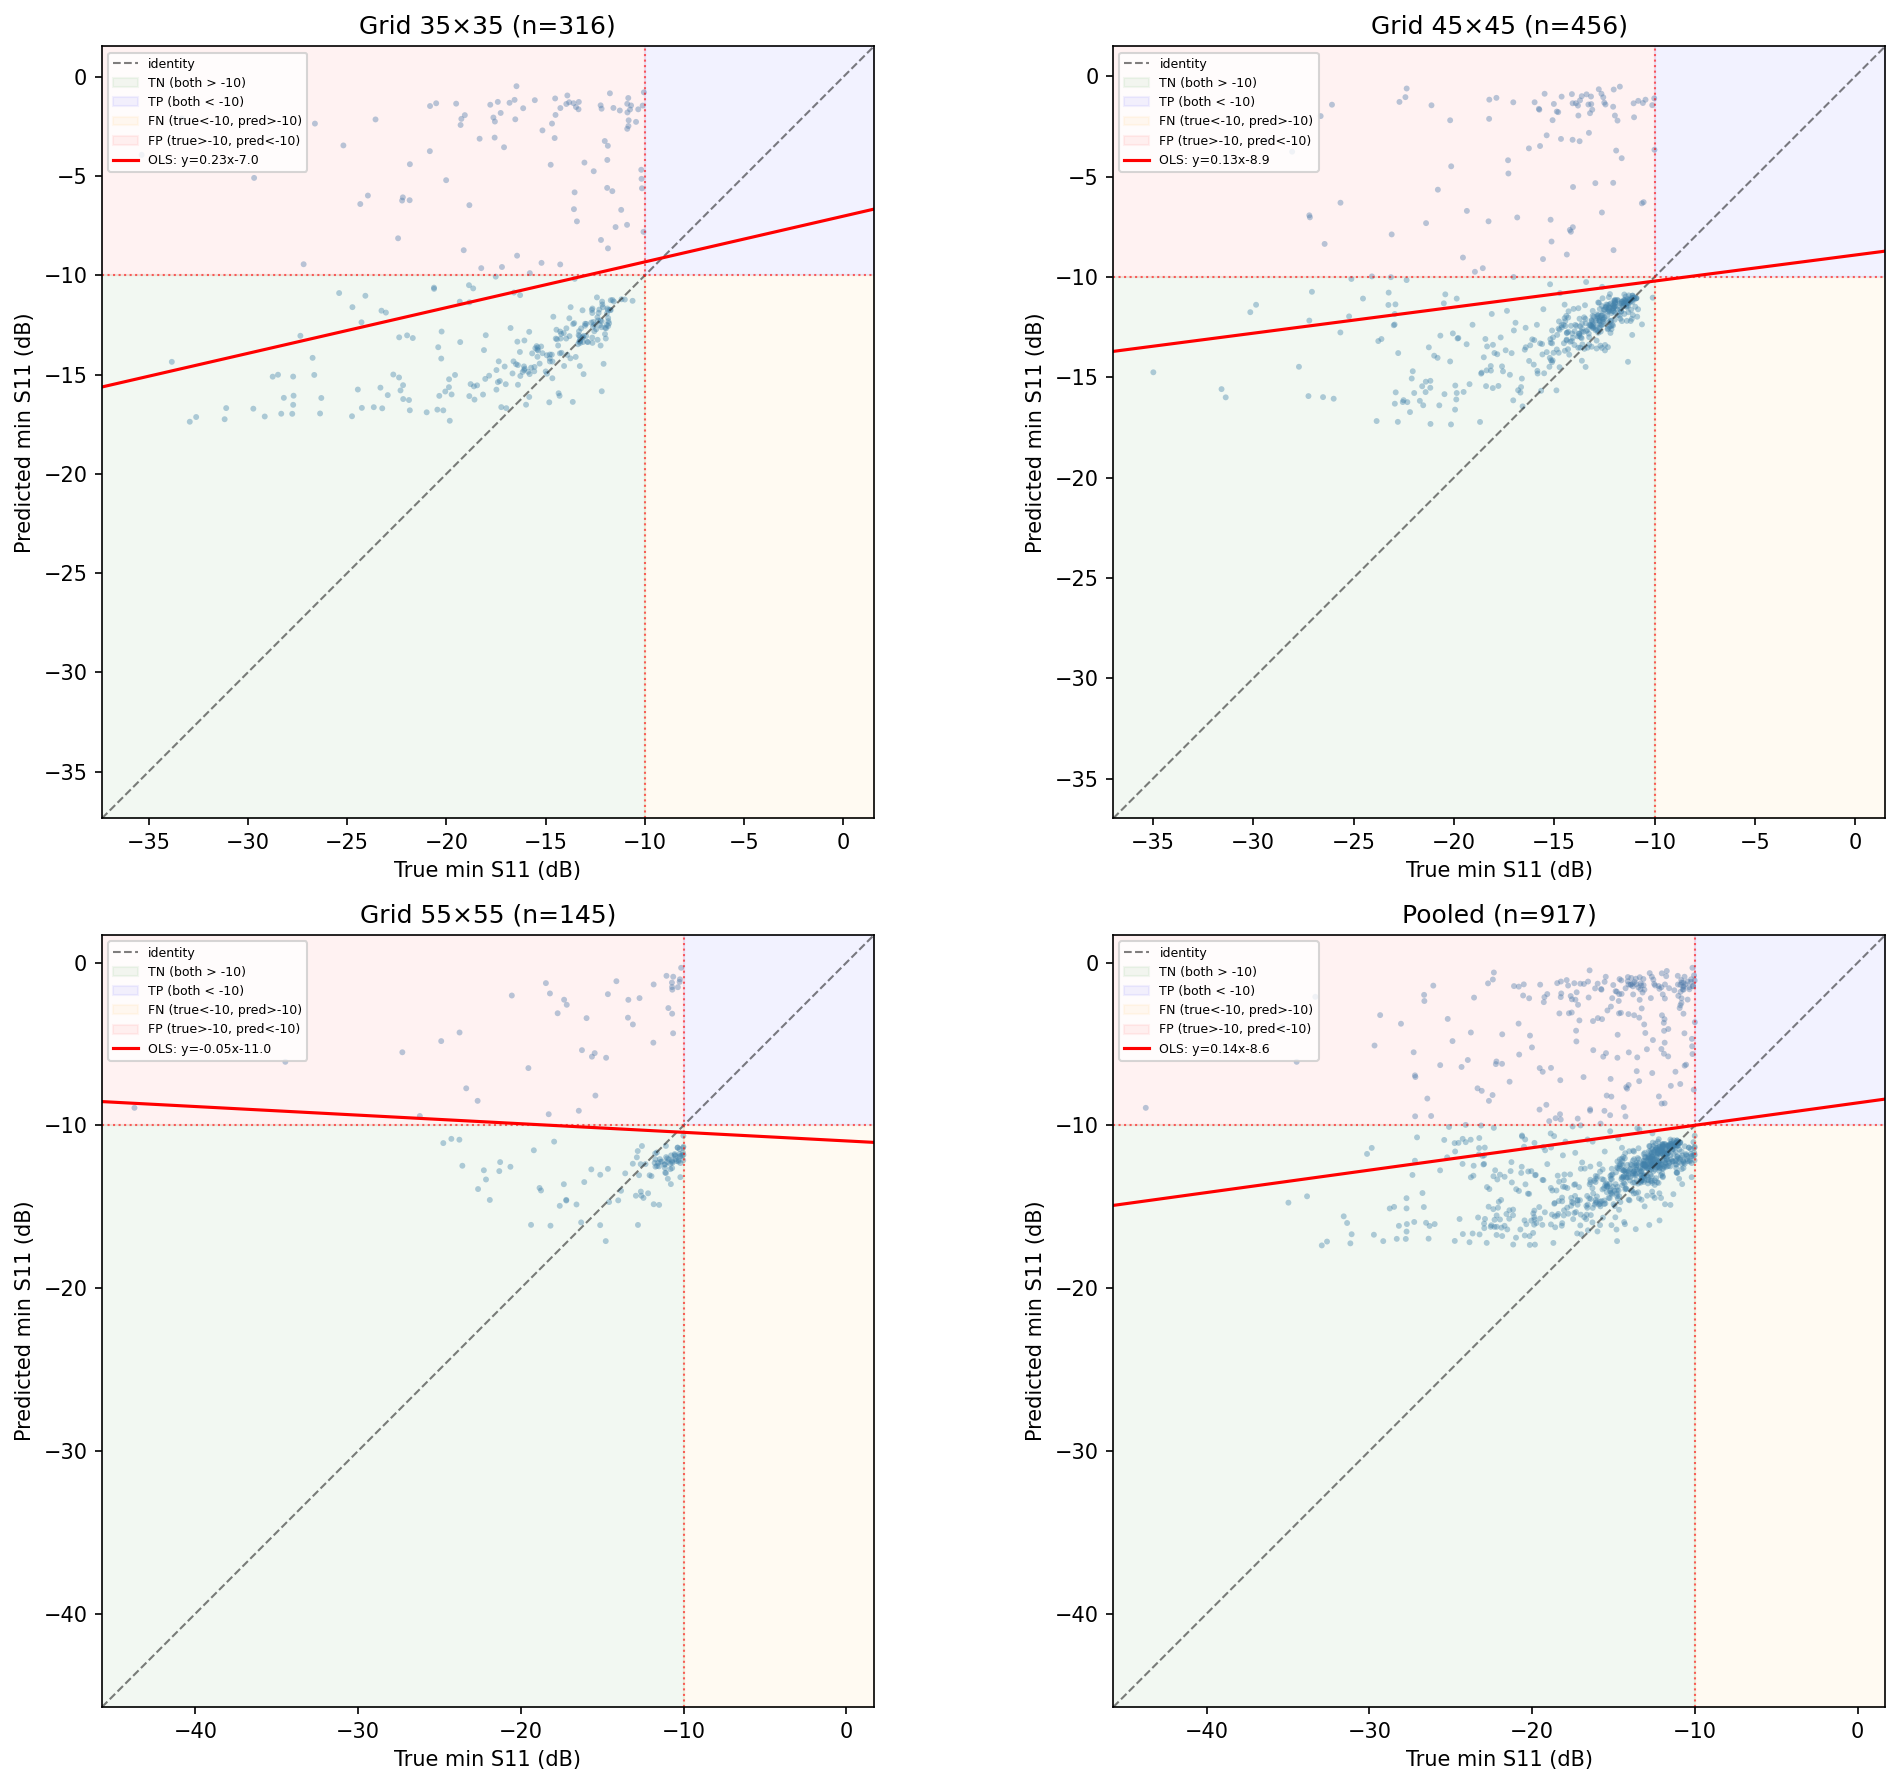

✓ Saved figures/ch21_min_scatter.png
✓ Saved artifacts/ch21_calibration_coeffs.json

INTERPRETATION (for context, not a decision)
  Pooled: |depth_bias| = 4.92 dB (94% of depth_error 5.26 dB)
  Calibrated residual MAE = 5.60 dB (106% of depth_error)
  → Bias is the dominant share → the depth problem is partially calibratable.


In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL B — Predicted vs True Minimum Scatter
# ═══════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
from scipy import stats as scipy_stats

func_df = df[df['is_functioning']].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

calibration_coeffs = {}

subsets = [(35, 'Grid 35×35'), (45, 'Grid 45×45'), (55, 'Grid 55×55'), ('pooled', 'Pooled')]

for ax_idx, (key, title) in enumerate(subsets):
    ax = axes[ax_idx]
    if key == 'pooled':
        sub = func_df
    else:
        sub = func_df[func_df['grid_size'] == key]

    x = sub['true_min_db'].values
    y = sub['pred_min_db'].values

    # OLS fit
    slope, intercept, r_value, p_value, std_err = scipy_stats.linregress(x, y)
    r_sq = r_value ** 2
    residuals = y - (slope * x + intercept)
    residual_std = np.std(residuals)

    # Pearson and Spearman
    pearson_r, _ = scipy_stats.pearsonr(x, y)
    spearman_r, _ = scipy_stats.spearmanr(x, y)

    # Scatter
    ax.scatter(x, y, s=8, alpha=0.4, c='steelblue', edgecolors='none')

    # Identity line
    lims = [min(x.min(), y.min()) - 2, max(x.max(), y.max()) + 2]
    ax.plot(lims, lims, 'k--', alpha=0.5, lw=1, label='identity')

    # -10 dB decision lines
    ax.axhline(-10, color='red', ls=':', alpha=0.6, lw=1)
    ax.axvline(-10, color='red', ls=':', alpha=0.6, lw=1)

    # Shade the four quadrants
    ax.fill_between([lims[0], -10], lims[0], -10, alpha=0.05, color='green',
                    label='TN (both > -10)')
    ax.fill_between([-10, lims[1]], -10, lims[1], alpha=0.05, color='blue',
                    label='TP (both < -10)')
    ax.fill_between([-10, lims[1]], lims[0], -10, alpha=0.05, color='orange',
                    label='FN (true<-10, pred>-10)')
    ax.fill_between([lims[0], -10], -10, lims[1], alpha=0.05, color='red',
                    label='FP (true>-10, pred<-10)')

    # OLS fit line
    x_fit = np.linspace(lims[0], lims[1], 100)
    ax.plot(x_fit, slope * x_fit + intercept, 'r-', lw=1.5,
            label=f'OLS: y={slope:.2f}x{intercept:+.1f}')

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('True min S11 (dB)')
    ax.set_ylabel('Predicted min S11 (dB)')
    ax.set_title(f'{title} (n={len(sub)})')
    ax.legend(fontsize=6, loc='upper left')
    ax.set_aspect('equal')

    # Print OLS stats
    print(f'\n--- {title} (is_functioning=True, n={len(sub)}) ---')
    print(f'  OLS slope a = {slope:.4f}')
    print(f'  OLS intercept b = {intercept:.4f}')
    print(f'  R² = {r_sq:.4f}')
    print(f'  Residual std = {residual_std:.4f}')
    print(f'  Pearson r = {pearson_r:.4f}')
    print(f'  Spearman ρ = {spearman_r:.4f}')

    # Bias/variance decomposition
    depth_err = np.abs(y - x).mean()
    depth_bias_val = (y - x).mean()

    # Calibrated prediction using OLS coefficients fit on this validation set
    min_cal = slope * y + intercept  # affine calibration of pred_min
    cal_residual_mae = np.abs(min_cal - x).mean()

    print(f'  depth_error = {depth_err:.2f} dB')
    print(f'  |depth_bias| = {abs(depth_bias_val):.2f} dB')
    print(f'  residual MAE after per-grid affine calibration = {cal_residual_mae:.2f} dB')

    calibration_coeffs[str(key)] = {
        'slope': float(slope),
        'intercept': float(intercept),
        'r_sq': float(r_sq),
        'residual_std': float(residual_std),
        'pearson_r': float(pearson_r),
        'spearman_r': float(spearman_r),
        'depth_error': float(depth_err),
        'depth_bias': float(depth_bias_val),
        'calibrated_residual_mae': float(cal_residual_mae),
    }

plt.tight_layout()
fig.savefig(f'{DATA_ROOT}/figures/ch21_min_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'✓ Saved figures/ch21_min_scatter.png')

with open(f'{DATA_ROOT}/artifacts/ch21_calibration_coeffs.json', 'w') as f:
    json.dump(calibration_coeffs, f, indent=2)
print(f'✓ Saved artifacts/ch21_calibration_coeffs.json')

# ── Interpretation ──
print('\n' + '=' * 80)
print('INTERPRETATION (for context, not a decision)')
print('=' * 80)
pooled_cc = calibration_coeffs['pooled']
bias_share = abs(pooled_cc['depth_bias']) / pooled_cc['depth_error'] * 100
resid_share = pooled_cc['calibrated_residual_mae'] / pooled_cc['depth_error'] * 100
print(f'  Pooled: |depth_bias| = {abs(pooled_cc["depth_bias"]):.2f} dB '
      f'({bias_share:.0f}% of depth_error {pooled_cc["depth_error"]:.2f} dB)')
print(f'  Calibrated residual MAE = {pooled_cc["calibrated_residual_mae"]:.2f} dB '
      f'({resid_share:.0f}% of depth_error)')
if bias_share > 50:
    print('  → Bias is the dominant share → the depth problem is partially calibratable.')
elif resid_share > 70:
    print('  → Residual std dominates → calibration alone will not fix depth accuracy.')
else:
    print('  → Mixed: bias is a meaningful share but residual variance is also large.')
    print('    Expect partial credit from calibration, not a full fix.')

---
## Cell C — The Ranking Question: Is the Information There?

Detection at any threshold is a 1-D classifier on `pred_min_db`. Compute
AUROC, Average Precision, and a full threshold sweep. Select and print
τ* three ways.

AUROC and Average Precision
Grid     AUROC      Avg Precision   N     
---------------------------------------------
35       0.9402     0.9677          499   
45       0.9455     0.9724          698   
55       0.8097     0.8350          299   
pooled   0.9103     0.9444          1496  

✓ Saved artifacts/ch21_threshold_sweep.csv (116 rows)


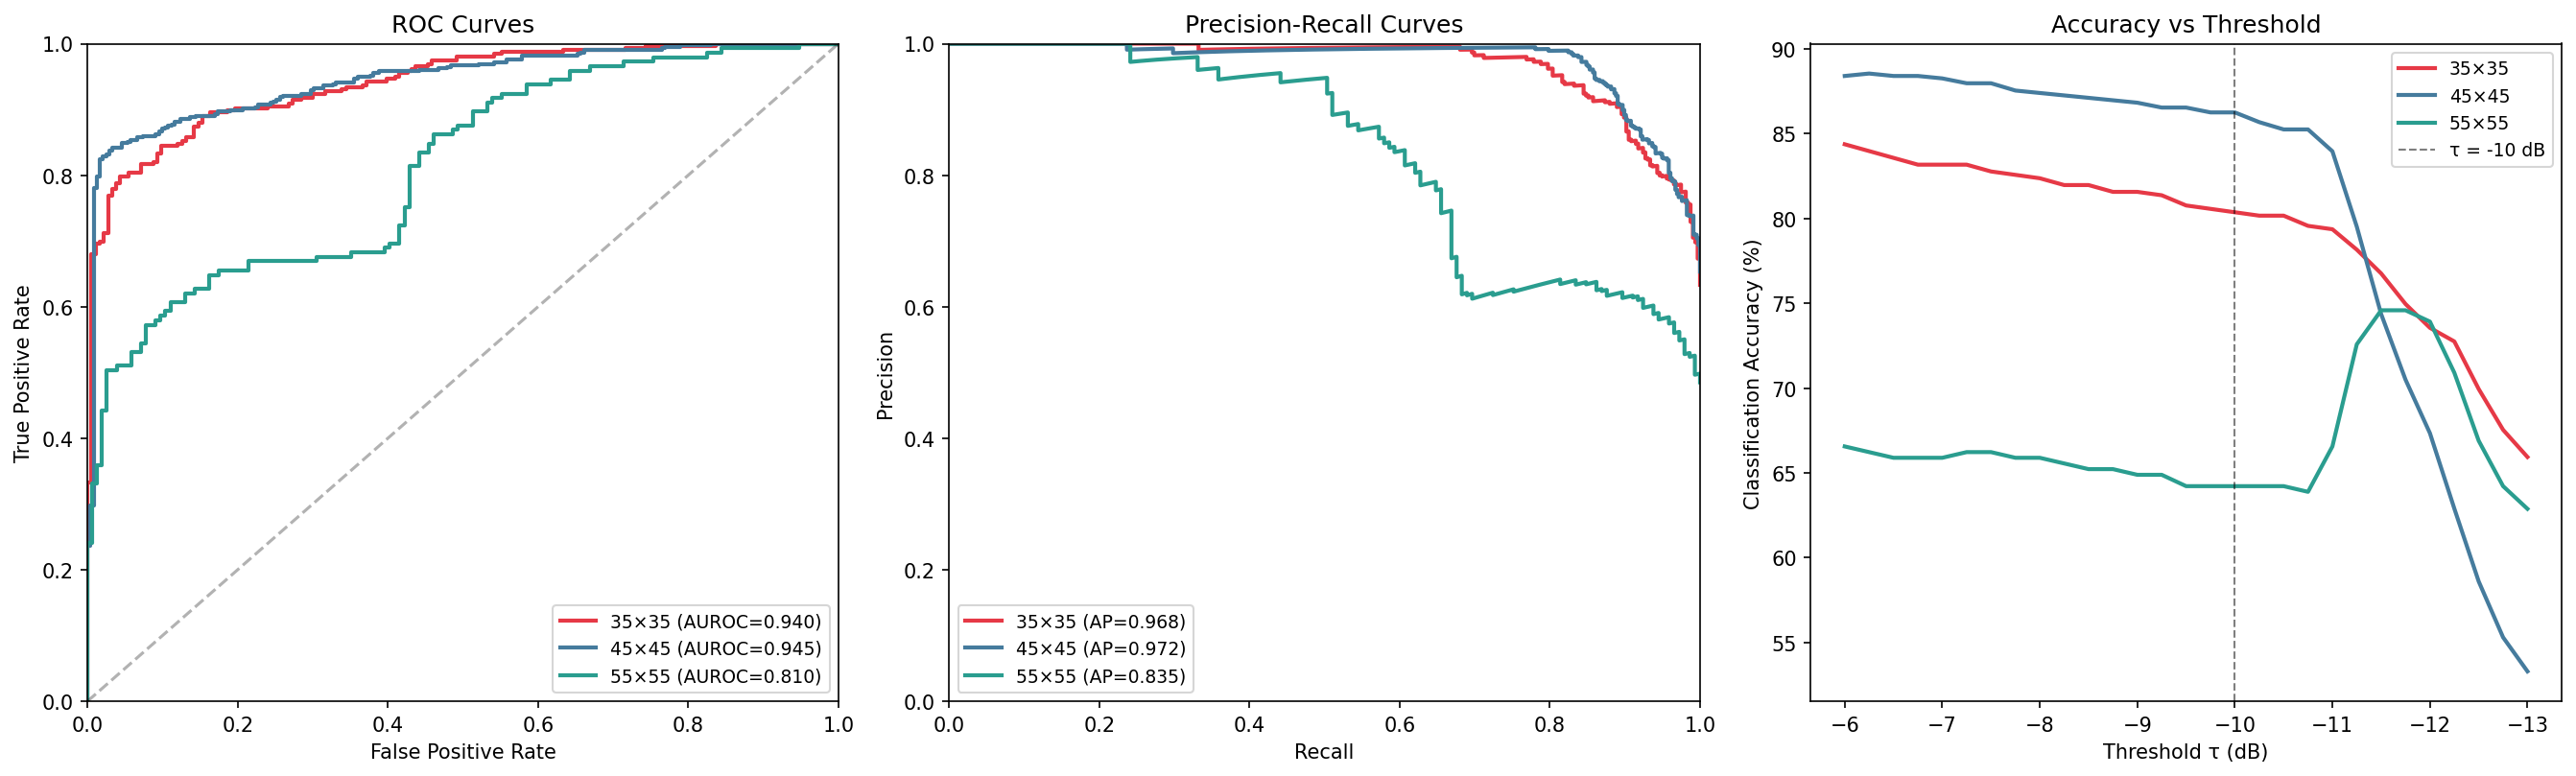

✓ Saved figures/ch21_roc_pr_sweep.png

OPTIMAL THRESHOLD SELECTION

τ*_bal = -6.00 dB (maximises pooled balanced accuracy = 83.2%)
τ*_acc = -6.00 dB (maximises pooled raw accuracy = 82.7%)

τ*_grid (per-grid argmax of balanced accuracy):
  35×35: τ* = -6.00 dB (balanced accuracy = 87.0%)
  45×45: τ* = -7.50 dB (balanced accuracy = 90.4%)
  55×55: τ* = -11.50 dB (balanced accuracy = 74.2%)

  CAVEAT: a per-grid threshold is defensible only because grid size is
  known at inference time — the model receives (N×N + 1) nodes, so N is
  observable. State this explicitly in any claim that uses per-grid τ.

Class accuracy at τ*_bal = -6.00 dB:
  35      : acc=84.4% bal_acc=87.0%
  45      : acc=88.4% bal_acc=90.0%
  55      : acc=66.6% bal_acc=66.8%
  pooled  : acc=82.7% bal_acc=83.2%


In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL C — The Ranking Question: Is the Information There?
# ═══════════════════════════════════════════════════════════════════════════

from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, f1_score, precision_score, recall_score

# Score = -pred_min_db: higher score = more likely functioning
# (because a more negative pred_min_db = deeper dip = more likely resonant)

roc_data = {}
pr_data = {}

print('=' * 80)
print('AUROC and Average Precision')
print('=' * 80)
print(f'{"Grid":<8} {"AUROC":<10} {"Avg Precision":<15} {"N":<6}')
print('-' * 45)

for key in [35, 45, 55, 'pooled']:
    if key == 'pooled':
        sub = df
    else:
        sub = df[df['grid_size'] == key]

    labels = sub['is_functioning'].astype(int).values
    scores = -sub['pred_min_db'].values  # higher = more likely functioning

    auroc = roc_auc_score(labels, scores)
    avg_prec = average_precision_score(labels, scores)

    fpr, tpr, _ = roc_curve(labels, scores)
    prec, rec, _ = precision_recall_curve(labels, scores)

    roc_data[key] = (fpr, tpr, auroc)
    pr_data[key] = (rec, prec, avg_prec)

    print(f'{str(key):<8} {auroc:<10.4f} {avg_prec:<15.4f} {len(sub):<6}')

# ── Full threshold sweep ──
tau_values = np.arange(-6.0, -13.25, -0.25)

sweep_rows = []

for key in [35, 45, 55, 'pooled']:
    if key == 'pooled':
        sub = df
    else:
        sub = df[df['grid_size'] == key]

    labels = sub['is_functioning'].astype(int).values
    pred_mins = sub['pred_min_db'].values

    for tau in tau_values:
        pred_func = (pred_mins < tau).astype(int)

        acc = (pred_func == labels).mean()
        bal_acc = balanced_accuracy_score(labels, pred_func)

        # For precision/recall/F1, treat functioning as positive class
        if pred_func.sum() > 0 and labels.sum() > 0:
            prec_val = precision_score(labels, pred_func, zero_division=0)
            rec_val = recall_score(labels, pred_func, zero_division=0)
            f1_val = f1_score(labels, pred_func, zero_division=0)
        else:
            prec_val = 0.0
            rec_val = 0.0
            f1_val = 0.0

        cm = confusion_matrix(labels, pred_func, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        sweep_rows.append({
            'grid': str(key),
            'tau': float(tau),
            'class_accuracy': float(acc),
            'precision': float(prec_val),
            'recall': float(rec_val),
            'f1': float(f1_val),
            'balanced_accuracy': float(bal_acc),
            'TP': int(tp),
            'TN': int(tn),
            'FP': int(fp),
            'FN': int(fn),
        })

sweep_df = pd.DataFrame(sweep_rows)
sweep_df.to_csv(f'{DATA_ROOT}/artifacts/ch21_threshold_sweep.csv', index=False)
print(f'\n✓ Saved artifacts/ch21_threshold_sweep.csv ({len(sweep_df)} rows)')

# ── Figures: ROC, PR, and accuracy-vs-tau ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

colors = {35: '#e63946', 45: '#457b9d', 55: '#2a9d8f'}

# ROC per grid
ax = axes[0]
for g in [35, 45, 55]:
    fpr, tpr, auroc = roc_data[g]
    ax.plot(fpr, tpr, color=colors[g], lw=2, label=f'{g}×{g} (AUROC={auroc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# PR per grid
ax = axes[1]
for g in [35, 45, 55]:
    rec, prec, avg_p = pr_data[g]
    ax.plot(rec, prec, color=colors[g], lw=2, label=f'{g}×{g} (AP={avg_p:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend(fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Accuracy vs tau per grid
ax = axes[2]
for g in [35, 45, 55]:
    sub_sweep = sweep_df[sweep_df['grid'] == str(g)]
    ax.plot(sub_sweep['tau'], sub_sweep['class_accuracy'] * 100,
            color=colors[g], lw=2, label=f'{g}×{g}')
ax.axvline(-10, color='black', ls='--', alpha=0.5, lw=1, label='τ = -10 dB')
ax.set_xlabel('Threshold τ (dB)')
ax.set_ylabel('Classification Accuracy (%)')
ax.set_title('Accuracy vs Threshold')
ax.legend(fontsize=9)
ax.invert_xaxis()

plt.tight_layout()
fig.savefig(f'{DATA_ROOT}/figures/ch21_roc_pr_sweep.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'✓ Saved figures/ch21_roc_pr_sweep.png')

# ── Select and print τ* three ways ──
print('\n' + '=' * 80)
print('OPTIMAL THRESHOLD SELECTION')
print('=' * 80)

# τ*_bal: maximises pooled balanced accuracy
pooled_sweep = sweep_df[sweep_df['grid'] == 'pooled']
best_bal_row = pooled_sweep.loc[pooled_sweep['balanced_accuracy'].idxmax()]
tau_star_bal = best_bal_row['tau']
print(f'\nτ*_bal = {tau_star_bal:.2f} dB (maximises pooled balanced accuracy = '
      f'{best_bal_row["balanced_accuracy"]*100:.1f}%)')

# τ*_acc: maximises pooled raw accuracy
best_acc_row = pooled_sweep.loc[pooled_sweep['class_accuracy'].idxmax()]
tau_star_acc = best_acc_row['tau']
print(f'τ*_acc = {tau_star_acc:.2f} dB (maximises pooled raw accuracy = '
      f'{best_acc_row["class_accuracy"]*100:.1f}%)')

# τ*_grid: per-grid argmax of balanced accuracy
print(f'\nτ*_grid (per-grid argmax of balanced accuracy):')
tau_star_grid = {}
for g in [35, 45, 55]:
    g_sweep = sweep_df[sweep_df['grid'] == str(g)]
    best_g_row = g_sweep.loc[g_sweep['balanced_accuracy'].idxmax()]
    tau_star_grid[g] = best_g_row['tau']
    print(f'  {g}×{g}: τ* = {best_g_row["tau"]:.2f} dB '
          f'(balanced accuracy = {best_g_row["balanced_accuracy"]*100:.1f}%)')

print('\n  CAVEAT: a per-grid threshold is defensible only because grid size is')
print('  known at inference time — the model receives (N×N + 1) nodes, so N is')
print('  observable. State this explicitly in any claim that uses per-grid τ.')

# Print class accuracy at τ*_bal for each grid
print(f'\nClass accuracy at τ*_bal = {tau_star_bal:.2f} dB:')
for key in [35, 45, 55, 'pooled']:
    row = sweep_df[(sweep_df['grid'] == str(key)) &
                   (np.isclose(sweep_df['tau'], tau_star_bal))]
    if len(row) > 0:
        print(f'  {str(key):<8}: acc={row.iloc[0]["class_accuracy"]*100:.1f}% '
              f'bal_acc={row.iloc[0]["balanced_accuracy"]*100:.1f}%')

---
## Cell D — Size the Loss Pathology (v3 section 6.1)

Over the FINE-TUNE POOL (11,971 samples; streamed, not held in RAM):
count extreme normalized targets, analyse per-bin std, measure MSE
concentration from single-largest-|y| points, and report the dynamic range
of the per-point scale inversion.

In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL D — Size the Loss Pathology (v3 section 6.1)
# ═══════════════════════════════════════════════════════════════════════════

# Stream over the full fine-tune pool without loading all into RAM.
# pool_indices has 11,971 entries.

pool_ds = FinetuneDataset(pool_indices, processed_dir, s11_mean_cpu, s11_std_cpu)
pool_loader = DataLoader(pool_ds, batch_size=64, shuffle=False)

n_pool = len(pool_indices)
total_points = n_pool * 201

print(f'Fine-tune pool: {n_pool} samples, {total_points:,} total points')

# ── Task 1: Count normalized targets with |y| > thresholds ──
thresholds = [5, 10, 20, 50]
counts = {t: 0 for t in thresholds}

# ── Task 2: Per-bin counts of |y| > 5 ──
per_bin_extreme_count = np.zeros(201, dtype=np.int64)

# ── Task 3: For samples with |y| > 10, MSE share of largest-|y| point ──
mse_share_list = []

for batch in tqdm(pool_loader, desc='Loss pathology scan'):
    y_norm = batch.y.view(-1, 201).numpy()  # (B, 201) normalized
    y_raw = batch.y_raw.view(-1, 201).numpy()
    B = y_norm.shape[0]

    abs_y = np.abs(y_norm)

    for t in thresholds:
        counts[t] += int((abs_y > t).sum())

    per_bin_extreme_count += (abs_y > 5).sum(axis=0).astype(np.int64)

    # Task 3: samples with at least one |y| > 10 point
    for i in range(B):
        sample_abs = abs_y[i]  # (201,)
        if sample_abs.max() > 10:
            # MSE of this sample (treating y_norm as the "signal")
            sample_mse = (y_norm[i] ** 2).sum()
            if sample_mse > 0:
                largest_abs_idx = np.argmax(sample_abs)
                largest_contribution = y_norm[i, largest_abs_idx] ** 2
                mse_share_list.append(largest_contribution / sample_mse)

# ── Print Task 1 ──
print('\n' + '=' * 80)
print('TASK 1: Count of normalized targets with |y| > threshold')
print('=' * 80)
print(f'{"Threshold":<12} {"Count":<12} {"Share of total":<15}')
print('-' * 40)
for t in thresholds:
    share = counts[t] / total_points
    print(f'|y| > {t:<5}  {counts[t]:<12,} {share*100:<15.4f}%')

# ── Print Task 2 ──
print('\n' + '=' * 80)
print('TASK 2: Per-bin s11_std and count of |y| > 5')
print('=' * 80)

# The 10 bins with smallest std
std_vals = s11_std_np.copy()
sorted_bin_indices = np.argsort(std_vals)
print(f'\nTen bins with SMALLEST s11_std (most tightly distributed):')
print(f'{"Bin":<6} {"Freq (GHz)":<12} {"s11_std":<10} {"n(|y|>5)":<10}')
print('-' * 40)
for bi in sorted_bin_indices[:10]:
    print(f'{bi:<6} {freq_axis[bi]:<12.4f} {std_vals[bi]:<10.4f} {per_bin_extreme_count[bi]:<10}')

# ── Print Task 3 ──
print('\n' + '=' * 80)
print('TASK 3: MSE share of single largest-|y| point (samples with |y| > 10)')
print('=' * 80)

if len(mse_share_list) > 0:
    mse_shares = np.array(mse_share_list)
    median_share = np.median(mse_shares)
    p90_share = np.percentile(mse_shares, 90)
    print(f'  Number of samples with at least one |y| > 10: {len(mse_shares)}')
    print(f'  Median MSE share of single largest-|y| point: {median_share*100:.1f}%')
    print(f'  90th percentile MSE share: {p90_share*100:.1f}%')
else:
    print('  No samples with |y| > 10 found.')

# ── Print Task 4 ──
print('\n' + '=' * 80)
print('TASK 4: Dynamic range of per-point scale inversion')
print('=' * 80)

std_sq = std_vals ** 2
mean_std_sq = std_sq.mean()
ratio_std_sq = std_sq.max() / std_sq.min()
print(f'  mean(s11_std²) = {mean_std_sq:.4f}')
print(f'  max(s11_std²) / min(s11_std²) = {ratio_std_sq:.1f}')
print(f'  This is the dynamic range of the per-point scale inversion.')
print(f'  Chunk 22 arm L2 removes this by per-frequency weighting.')

# ── Save CSV ──
pathology_rows = []
for bi in range(201):
    pathology_rows.append({
        'bin': bi,
        'freq_ghz': float(freq_axis[bi]),
        's11_std': float(std_vals[bi]),
        's11_std_sq': float(std_sq[bi]),
        'n_abs_y_gt_5': int(per_bin_extreme_count[bi]),
    })
pathology_df = pd.DataFrame(pathology_rows)
pathology_df.to_csv(f'{DATA_ROOT}/artifacts/ch21_loss_pathology.csv', index=False)
print(f'\n✓ Saved artifacts/ch21_loss_pathology.csv')

Fine-tune pool: 11971 samples, 2,406,171 total points


Loss pathology scan:   0%|          | 0/188 [00:00<?, ?it/s]


TASK 1: Count of normalized targets with |y| > threshold
Threshold    Count        Share of total 
----------------------------------------
|y| > 5      8,955        0.3722         %
|y| > 10     1,280        0.0532         %
|y| > 20     125          0.0052         %
|y| > 50     7            0.0003         %

TASK 2: Per-bin s11_std and count of |y| > 5

Ten bins with SMALLEST s11_std (most tightly distributed):
Bin    Freq (GHz)   s11_std    n(|y|>5)  
----------------------------------------
0      1.0000       0.0139     0         
1      1.0150       0.0145     0         
2      1.0300       0.0150     0         
3      1.0450       0.0156     0         
4      1.0600       0.0162     0         
5      1.0750       0.0168     0         
6      1.0900       0.0174     0         
7      1.1050       0.0180     0         
8      1.1200       0.0186     0         
9      1.1350       0.0192     0         

TASK 3: MSE share of single largest-|y| point (samples with |y| > 10)
  Numbe

---
## Cell E — The Label-Margin Bound

This bounds what **any** model can achieve. Per grid, on validation, over ALL
samples: histogram of the signed margin m = true_min_db − (−10.0).

If the true minimum is near −10 dB, even a perfect depth predictor will
misclassify about half of those samples.

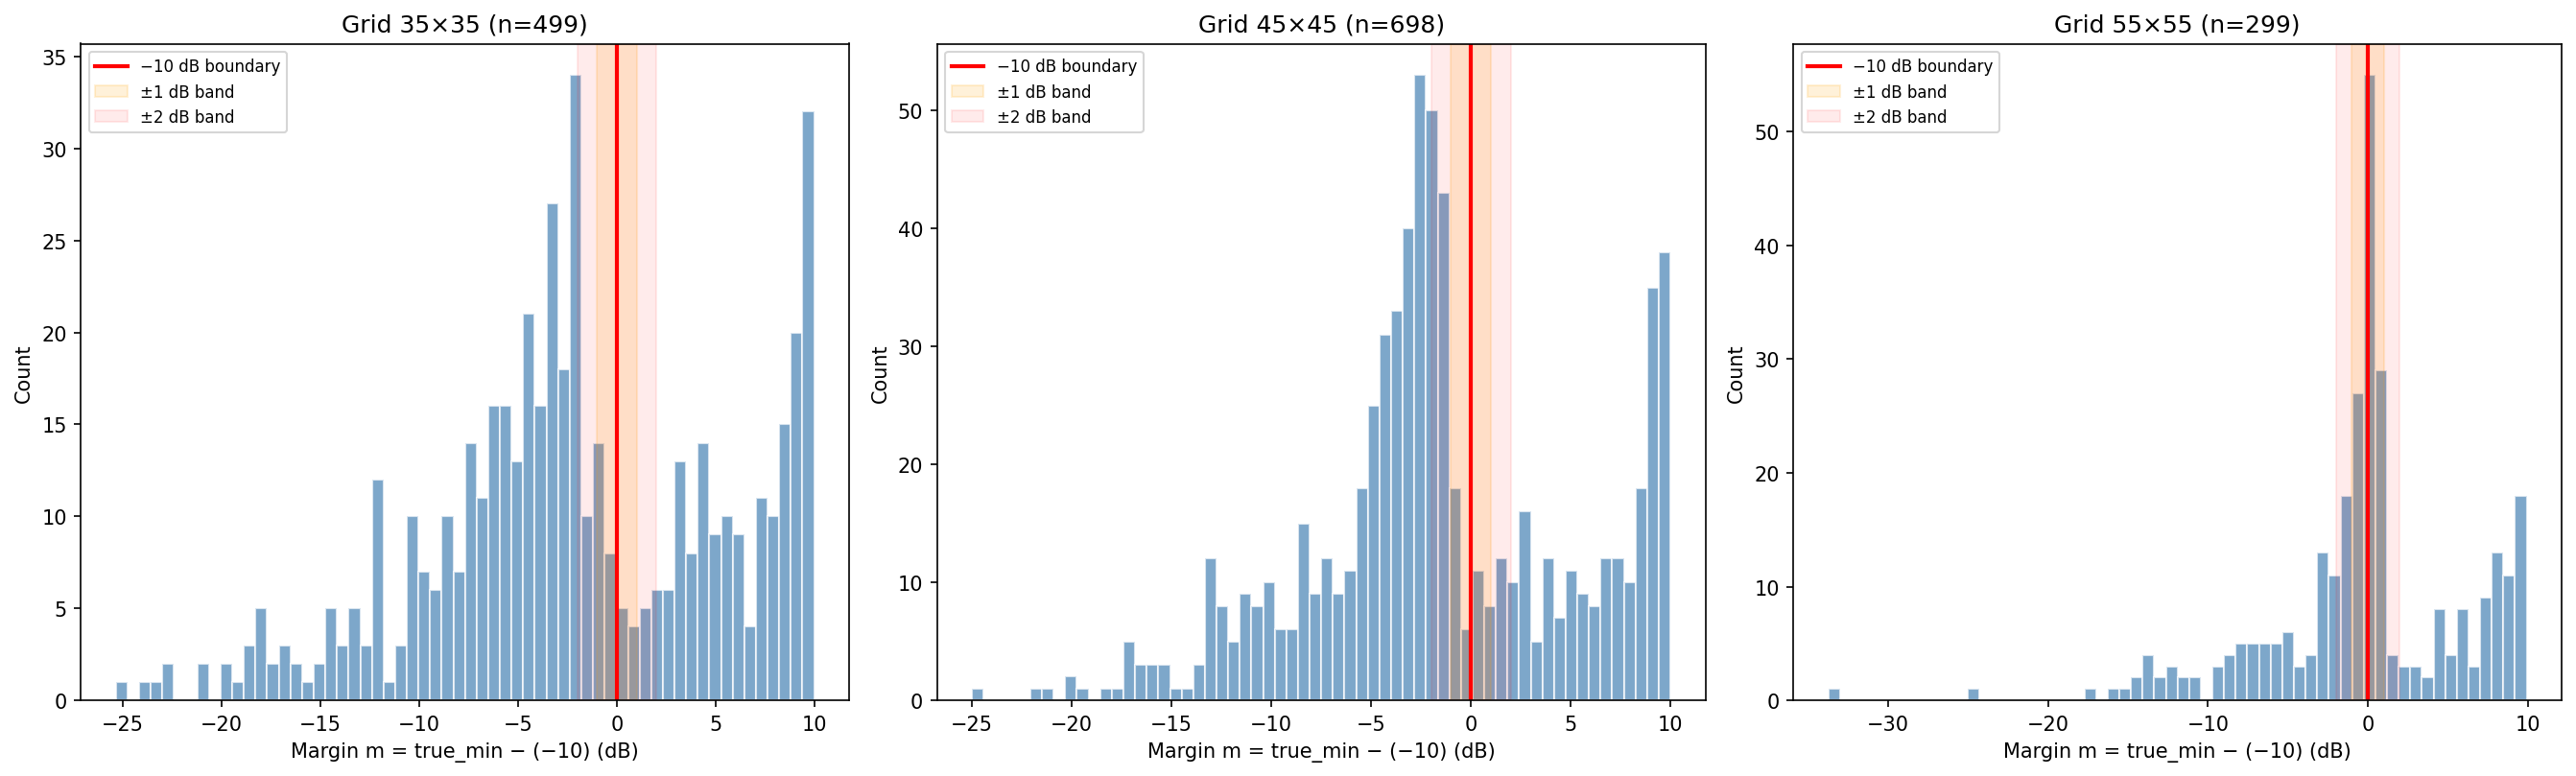

✓ Saved figures/ch21_label_margin.png

MARGIN STATISTICS (all samples)

  Grid 35×35 (n=499):
    Share with |m| < 0.5 dB: 2.6%
    Share with |m| < 1.0 dB: 5.6%
    Share with |m| < 2.0 dB: 12.4%
    Median true_min_db: -12.45 dB

  Grid 45×45 (n=698):
    Share with |m| < 0.5 dB: 2.0%
    Share with |m| < 1.0 dB: 5.2%
    Share with |m| < 2.0 dB: 17.6%
    Median true_min_db: -12.24 dB

  Grid 55×55 (n=299):
    Share with |m| < 0.5 dB: 21.4%
    Share with |m| < 1.0 dB: 36.5%
    Share with |m| < 2.0 dB: 47.2%
    Median true_min_db: -9.95 dB

IMPLIED ACCURACY CEILING

Formula: acc_ceiling ≈ 1 - P(|m| < d) × 0.5
  where d = predictor depth error, m = true_min - (-10).
  Rough bound (not a theorem): assumes samples inside the margin band
  are coin flips and samples outside are always right.

Grid      d=5.2 dB    d=3.0 dB    d=2.0 dB    d=1.0 dB  
------------------------------------------------------------
35          77.3%       88.8%       93.8%       97.2%   
45          72.0%  

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL E — The Label-Margin Bound
# ═══════════════════════════════════════════════════════════════════════════

df['margin'] = df['true_min_db'] - (-10.0)  # positive = above -10, negative = below -10

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax_idx, g in enumerate([35, 45, 55]):
    ax = axes[ax_idx]
    sub = df[df['grid_size'] == g]
    margins = sub['margin'].values

    ax.hist(margins, bins=60, color='steelblue', alpha=0.7, edgecolor='white', lw=0.5)
    ax.axvline(0, color='red', ls='-', lw=2, label='−10 dB boundary')

    # Shade ±1 and ±2 dB bands
    ax.axvspan(-1, 1, alpha=0.15, color='orange', label='±1 dB band')
    ax.axvspan(-2, 2, alpha=0.08, color='red', label='±2 dB band')

    ax.set_xlabel('Margin m = true_min − (−10) (dB)')
    ax.set_ylabel('Count')
    ax.set_title(f'Grid {g}×{g} (n={len(sub)})')
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(f'{DATA_ROOT}/figures/ch21_label_margin.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'✓ Saved figures/ch21_label_margin.png')

# ── Print margin statistics ──
print('\n' + '=' * 80)
print('MARGIN STATISTICS (all samples)')
print('=' * 80)

for g in [35, 45, 55]:
    sub = df[df['grid_size'] == g]
    margins = sub['margin'].values
    abs_margins = np.abs(margins)

    n = len(sub)
    share_05 = (abs_margins < 0.5).mean()
    share_10 = (abs_margins < 1.0).mean()
    share_20 = (abs_margins < 2.0).mean()

    print(f'\n  Grid {g}×{g} (n={n}):')
    print(f'    Share with |m| < 0.5 dB: {share_05*100:.1f}%')
    print(f'    Share with |m| < 1.0 dB: {share_10*100:.1f}%')
    print(f'    Share with |m| < 2.0 dB: {share_20*100:.1f}%')
    print(f'    Median true_min_db: {sub["true_min_db"].median():.2f} dB')

# ── Implied accuracy ceiling ──
print('\n' + '=' * 80)
print('IMPLIED ACCURACY CEILING')
print('=' * 80)
print('\nFormula: acc_ceiling ≈ 1 - P(|m| < d) × 0.5')
print('  where d = predictor depth error, m = true_min - (-10).')
print('  Rough bound (not a theorem): assumes samples inside the margin band')
print('  are coin flips and samples outside are always right.\n')

depth_errors_test = [5.2, 3.0, 2.0, 1.0]
print(f'{"Grid":<8}', end='')
for d in depth_errors_test:
    print(f'  d={d:.1f} dB  ', end='')
print()
print('-' * 60)

for g in [35, 45, 55]:
    sub = df[df['grid_size'] == g]
    abs_margins = np.abs(sub['margin'].values)
    print(f'{g:<8}', end='')
    for d in depth_errors_test:
        p_in_band = (abs_margins < d).mean()
        ceiling = 1.0 - p_in_band * 0.5
        print(f'  {ceiling*100:>6.1f}%   ', end='')
    print()

# ── Margin shares by is_functioning ──
print('\n' + '=' * 80)
print('MARGIN SHARES BY is_functioning')
print('=' * 80)

for g in [35, 45, 55]:
    sub = df[df['grid_size'] == g]
    for func_label, func_name in [(True, 'functioning'), (False, 'non-functioning')]:
        fsub = sub[sub['is_functioning'] == func_label]
        if len(fsub) == 0:
            continue
        abs_margins = np.abs(fsub['margin'].values)
        print(f'  Grid {g}×{g}, {func_name} (n={len(fsub)}):')
        print(f'    |m| < 0.5: {(abs_margins < 0.5).mean()*100:.1f}%  '
              f'|m| < 1.0: {(abs_margins < 1.0).mean()*100:.1f}%  '
              f'|m| < 2.0: {(abs_margins < 2.0).mean()*100:.1f}%')

# ── Context for 55x55 ──
sub55 = df[df['grid_size'] == 55]
print(f'\n  Context for 55×55: median true_min_db = {sub55["true_min_db"].median():.2f} dB')
print(f'  The −10 dB decision boundary cuts through the middle of the distribution.')

---
## Cell F — The find_peaks Edge-Clipping Audit

`scipy.signal.find_peaks` cannot return an index at 0 or 200, so a resonance
whose dip is clipped by the band edge is invisible to a peak-based detector.
Compare the minimum-based detector (min(pred) < −10) against the find_peaks
detector and quantify the disagreement.

In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL F — The find_peaks Edge-Clipping Audit
# ═══════════════════════════════════════════════════════════════════════════

# Re-run inference to get full predicted curves for the find_peaks comparison.
# (We already have true_argmin_bin and pred_argmin_bin in df.)

edge_bins = {0, 1, 2, 198, 199, 200}

# Count true-functioning samples whose true_argmin_bin is at an edge
func_val = df[df['is_functioning']]
true_at_edge = func_val['true_argmin_bin'].isin(edge_bins).sum()
true_at_edge_share = true_at_edge / len(func_val) if len(func_val) > 0 else 0

# Count predicted curves whose pred_argmin_bin is at an edge
pred_at_edge = df['pred_argmin_bin'].isin(edge_bins).sum()
pred_at_edge_share = pred_at_edge / len(df) if len(df) > 0 else 0

print('=' * 80)
print('EDGE-CLIPPING AUDIT')
print('=' * 80)
print(f'\n  True-functioning samples with true_argmin_bin at edge {sorted(edge_bins)}:')
print(f'    Count: {true_at_edge} / {len(func_val)} ({true_at_edge_share*100:.1f}%)')
print(f'\n  All samples with pred_argmin_bin at edge:')
print(f'    Count: {pred_at_edge} / {len(df)} ({pred_at_edge_share*100:.1f}%)')

# ── Implement both detectors side by side ──
# Detector 1 (minimum-based): pred_func = min(pred) < -10
# Detector 2 (find_peaks-based): find_peaks(-pred, height=10, distance=5)

# We need the full predicted curves. Re-run inference.
all_pred_curves = []
all_true_curves = []
with torch.no_grad():
    for batch in tqdm(val_loader, desc='Re-inference for find_peaks'):
        batch = batch.to(device)
        pred_norm = model(batch)
        pred_db = pred_norm * s11_std_dev + s11_mean_dev
        true_db = batch.y_raw.squeeze(1).to(device)
        all_pred_curves.append(pred_db.detach().cpu().numpy())
        all_true_curves.append(true_db.detach().cpu().numpy())

all_pred_curves = np.concatenate(all_pred_curves, axis=0)  # (1496, 201)
all_true_curves = np.concatenate(all_true_curves, axis=0)
assert all_pred_curves.shape[0] == len(df)

# Apply both detectors
min_detector_pred_func = all_pred_curves.min(axis=1) < -10  # (1496,)

peaks_detector_pred_func = np.zeros(len(df), dtype=bool)
for i in range(len(df)):
    peaks, props = find_peaks(-all_pred_curves[i], height=10, distance=5)
    peaks_detector_pred_func[i] = len(peaks) > 0

# True labels
true_func_arr = df['is_functioning'].values

# Disagreement matrix
print('\n' + '-' * 60)
print('DETECTOR COMPARISON')
print('-' * 60)

both_detect = min_detector_pred_func & peaks_detector_pred_func
only_min = min_detector_pred_func & ~peaks_detector_pred_func
only_peaks = ~min_detector_pred_func & peaks_detector_pred_func
neither = ~min_detector_pred_func & ~peaks_detector_pred_func

print(f'\n  Disagreement matrix (all {len(df)} validation samples):')
print(f'                          find_peaks=YES  find_peaks=NO')
print(f'    min-based=YES         {both_detect.sum():>10}      {only_min.sum():>10}')
print(f'    min-based=NO          {only_peaks.sum():>10}      {neither.sum():>10}')

# Among true-functioning samples:
# How many are correctly caught by min(pred) < -10 but MISSED by find_peaks?
true_func_mask = df['is_functioning'].values
caught_by_min = min_detector_pred_func & true_func_mask
caught_by_peaks = peaks_detector_pred_func & true_func_mask
min_only_correct = caught_by_min & ~caught_by_peaks

n_true_func_total = true_func_mask.sum()
n_min_only_correct = min_only_correct.sum()
share_min_only = n_min_only_correct / n_true_func_total if n_true_func_total > 0 else 0

print(f'\n  Among true-functioning (n={n_true_func_total}):')
print(f'    Correctly caught by min-based detector: {caught_by_min.sum()}')
print(f'    Correctly caught by find_peaks detector: {caught_by_peaks.sum()}')
print(f'    Caught by min but MISSED by find_peaks: {n_min_only_correct} ({share_min_only*100:.1f}%)')

# Classification accuracy for both detectors
min_acc = (min_detector_pred_func == true_func_arr).mean()
peaks_acc = (peaks_detector_pred_func == true_func_arr).mean()
print(f'\n  Classification accuracy (tau=-10):')
print(f'    Min-based detector:       {min_acc*100:.1f}%')
print(f'    find_peaks-based detector: {peaks_acc*100:.1f}%')

if share_min_only > 0.02:
    print(f'\n  ⚠ RECOMMENDATION: {share_min_only*100:.1f}% > 2% of true-functioning samples')
    print(f'  are caught by min-based but missed by find_peaks. Classification should')
    print(f'  switch to the minimum-based detector everywhere, since it is free and')
    print(f'  strictly more sensitive.')
else:
    print(f'\n  ✓ Only {share_min_only*100:.1f}% of true-functioning samples are missed only')
    print(f'  by find_peaks. Edge clipping is not a significant issue.')

EDGE-CLIPPING AUDIT

  True-functioning samples with true_argmin_bin at edge [0, 1, 2, 198, 199, 200]:
    Count: 2 / 917 (0.2%)

  All samples with pred_argmin_bin at edge:
    Count: 258 / 1496 (17.2%)


Re-inference for find_peaks:   0%|          | 0/47 [00:00<?, ?it/s]


------------------------------------------------------------
DETECTOR COMPARISON
------------------------------------------------------------

  Disagreement matrix (all 1496 validation samples):
                          find_peaks=YES  find_peaks=NO
    min-based=YES                758               0
    min-based=NO                   0             738

  Among true-functioning (n=917):
    Correctly caught by min-based detector: 687
    Correctly caught by find_peaks detector: 687
    Caught by min but MISSED by find_peaks: 0 (0.0%)

  Classification accuracy (tau=-10):
    Min-based detector:       79.9%
    find_peaks-based detector: 79.9%

  ✓ Only 0.0% of true-functioning samples are missed only
  by find_peaks. Edge clipping is not a significant issue.


---
## Cell G — Pre-Registered Decision Gate

**Rule first, then data, then verdict.**

Three branches:
- **READOUT-SUFFICIENT**: AUROC ≥ 0.90 AND class_accuracy at τ\*_bal ≥ 0.88 pooled AND ≥ 0.80 at grid 55
- **LOSS-REQUIRED**: AUROC < 0.85 pooled OR grid-55 AUROC < 0.80
- **MIXED**: anything else

In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL G — Pre-Registered Decision Gate
# ═══════════════════════════════════════════════════════════════════════════

print('=' * 80)
print('PRE-REGISTERED DECISION GATE')
print('=' * 80)

# ── PRINT THE RULE FIRST ──
print("""
RULE (evaluated on validation):

  READOUT-SUFFICIENT:
    if pooled AUROC >= 0.90
    AND class_accuracy at τ*_bal >= 0.88 pooled
    AND class_accuracy at τ*_bal >= 0.80 at grid 55
    → the model already ranks antennas well; the accuracy deficit is a
      threshold artifact. Chunk 22 is then OPTIONAL for the classification
      claim (still worth one arm for the depth claim itself). Go to Chunk 24.

  LOSS-REQUIRED:
    if pooled AUROC < 0.85
    OR grid-55 AUROC < 0.80
    → ranking itself is poor, no threshold rescues it. Run Chunk 22 in full.

  MIXED:
    anything else, including the likely case that 35/45 recover fully and
    55 does not
    → run Chunk 22 Stage 1 only (control + L1 + L2), skip L3 unless Stage 1
      is also MIXED.
""")

# ── THEN THE DATA ──
print('-' * 80)
print('DATA')
print('-' * 80)

pooled_auroc = roc_data['pooled'][2]
g55_auroc = roc_data[55][2]

# Class accuracy at τ*_bal
pooled_bal_sweep = sweep_df[(sweep_df['grid'] == 'pooled') &
                            (np.isclose(sweep_df['tau'], tau_star_bal))]
g55_bal_sweep = sweep_df[(sweep_df['grid'] == '55') &
                         (np.isclose(sweep_df['tau'], tau_star_bal))]

pooled_acc_at_tau_bal = pooled_bal_sweep.iloc[0]['class_accuracy'] if len(pooled_bal_sweep) > 0 else 0.0
g55_acc_at_tau_bal = g55_bal_sweep.iloc[0]['class_accuracy'] if len(g55_bal_sweep) > 0 else 0.0

print(f'  Pooled AUROC:                        {pooled_auroc:.4f}')
print(f'  Grid 55 AUROC:                       {g55_auroc:.4f}')
print(f'  τ*_bal:                               {tau_star_bal:.2f} dB')
print(f'  Pooled class_acc at τ*_bal:           {pooled_acc_at_tau_bal*100:.1f}%')
print(f'  Grid 55 class_acc at τ*_bal:          {g55_acc_at_tau_bal*100:.1f}%')

for g in [35, 45]:
    g_auroc = roc_data[g][2]
    g_bal_sweep = sweep_df[(sweep_df['grid'] == str(g)) &
                           (np.isclose(sweep_df['tau'], tau_star_bal))]
    g_acc = g_bal_sweep.iloc[0]['class_accuracy'] if len(g_bal_sweep) > 0 else 0.0
    print(f'  Grid {g} AUROC:                       {g_auroc:.4f}')
    print(f'  Grid {g} class_acc at τ*_bal:          {g_acc*100:.1f}%')

# ── THEN THE VERDICT ──
print('\n' + '=' * 80)
print('VERDICT')
print('=' * 80)

# Evaluate the three branches
readout_sufficient = (pooled_auroc >= 0.90 and
                      pooled_acc_at_tau_bal >= 0.88 and
                      g55_acc_at_tau_bal >= 0.80)

loss_required = (pooled_auroc < 0.85 or g55_auroc < 0.80)

if readout_sufficient:
    branch = 'READOUT-SUFFICIENT'
    print(f'\n  Branch: {branch}')
    print(f'  Reason: pooled AUROC = {pooled_auroc:.3f} >= 0.90, '
          f'pooled acc@τ*_bal = {pooled_acc_at_tau_bal*100:.1f}% >= 88%, '
          f'g55 acc@τ*_bal = {g55_acc_at_tau_bal*100:.1f}% >= 80%')
    print(f'  → The model already ranks antennas well. Chunk 22 is OPTIONAL')
    print(f'    for the classification claim. Go to Chunk 24.')
    print(f'  Recommended next notebook: chunk24_*')

elif loss_required:
    branch = 'LOSS-REQUIRED'
    reasons = []
    if pooled_auroc < 0.85:
        reasons.append(f'pooled AUROC = {pooled_auroc:.3f} < 0.85')
    if g55_auroc < 0.80:
        reasons.append(f'g55 AUROC = {g55_auroc:.3f} < 0.80')
    print(f'\n  Branch: {branch}')
    print(f'  Reason: {"; ".join(reasons)}')
    print(f'  → Ranking itself is poor, no threshold rescues it.')
    print(f'    Run Chunk 22 in full.')
    print(f'  Recommended next notebook: chunk22_loss_engineering (full)')

else:
    branch = 'MIXED'
    print(f'\n  Branch: {branch}')
    print(f'  Reason: pooled AUROC = {pooled_auroc:.3f}, '
          f'g55 AUROC = {g55_auroc:.3f}, '
          f'pooled acc@τ*_bal = {pooled_acc_at_tau_bal*100:.1f}%, '
          f'g55 acc@τ*_bal = {g55_acc_at_tau_bal*100:.1f}%')
    print(f'  Falls between READOUT-SUFFICIENT and LOSS-REQUIRED.')
    print(f'  → Run Chunk 22 Stage 1 only (control + L1 + L2), skip L3 unless')
    print(f'    Stage 1 is also MIXED.')
    print(f'  Recommended next notebook: chunk22_loss_engineering (Stage 1 only)')

print(f'\n  DO NOT PROCEED PAST THIS CELL.')

PRE-REGISTERED DECISION GATE

RULE (evaluated on validation):

  READOUT-SUFFICIENT:
    if pooled AUROC >= 0.90
    AND class_accuracy at τ*_bal >= 0.88 pooled
    AND class_accuracy at τ*_bal >= 0.80 at grid 55
    → the model already ranks antennas well; the accuracy deficit is a
      threshold artifact. Chunk 22 is then OPTIONAL for the classification
      claim (still worth one arm for the depth claim itself). Go to Chunk 24.

  LOSS-REQUIRED:
    if pooled AUROC < 0.85
    OR grid-55 AUROC < 0.80
    → ranking itself is poor, no threshold rescues it. Run Chunk 22 in full.

  MIXED:
    anything else, including the likely case that 35/45 recover fully and
    55 does not
    → run Chunk 22 Stage 1 only (control + L1 + L2), skip L3 unless Stage 1
      is also MIXED.

--------------------------------------------------------------------------------
DATA
--------------------------------------------------------------------------------
  Pooled AUROC:                        0.9103
  

---
## Cell H — Guards

Behavioural guards to validate model architecture, parameter count,
permutation invariance, and split integrity.

In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL H — Guards
# ═══════════════════════════════════════════════════════════════════════════

print('=' * 80)
print('GUARDS')
print('=' * 80)

# ── (a) Assert 587,001 trainable parameters ──
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
assert n_total == 587_001, f'GUARD (a) FAILED: expected 587001 params, got {n_total}'
print(f'✓ Guard (a): model has {n_total:,} trainable parameters')

# ── (b) Assert len(model.blocks) == 4 and each entry has 2 sub-blocks ──
assert len(model.blocks) == 4, f'GUARD (b) FAILED: expected 4 blocks, got {len(model.blocks)}'
for i, block_pair in enumerate(model.blocks):
    assert len(block_pair) == 2, (
        f'GUARD (b) FAILED: block {i} has {len(block_pair)} sub-blocks, expected 2')
print(f'✓ Guard (b): model.blocks has 4 entries, each with 2 sub-blocks')

# ── (c) Permutation invariance sanity check ──
# Load one graph, run forward pass, then permute node order and check
# that output changes by < 1e-5 dB.
model.eval()
probe_data = val_ds[0]

with torch.no_grad():
    # Original forward pass
    batch_orig = DataLoader([probe_data], batch_size=1)
    batch_orig = next(iter(batch_orig)).to(device)
    pred_orig = model(batch_orig) * s11_std_dev + s11_mean_dev  # (1, 201)

    # Create a permuted version
    import copy
    perm_data = copy.deepcopy(probe_data)
    n_nodes = perm_data.x.shape[0]

    # Fixed permutation (seed=42 for reproducibility)
    rng = np.random.RandomState(42)
    perm = torch.tensor(rng.permutation(n_nodes), dtype=torch.long)
    inv_perm = torch.zeros_like(perm)
    inv_perm[perm] = torch.arange(n_nodes)

    # Permute node features
    perm_data.x = perm_data.x[perm]

    # Remap edge_index
    perm_data.edge_index = inv_perm[perm_data.edge_index]

    # Forward pass on permuted data
    batch_perm = DataLoader([perm_data], batch_size=1)
    batch_perm = next(iter(batch_perm)).to(device)
    pred_perm = model(batch_perm) * s11_std_dev + s11_mean_dev  # (1, 201)

    max_diff = (pred_orig - pred_perm).abs().max().item()

assert max_diff < 1e-5, (
    f'GUARD (c) FAILED: permutation changed output by {max_diff:.6f} dB (> 1e-5)')
print(f'✓ Guard (c): permutation invariance holds (max diff = {max_diff:.2e} dB)')

# ── (d) Validation record count and split disjointness ──
assert len(df) == 1496, f'GUARD (d) FAILED: expected 1496 val records, got {len(df)}'

# Convert to sets of (grid_size, local_idx) tuples for comparison
val_set = set(tuple(x) for x in val_indices)
test_set = set(tuple(x) for x in test_indices)
overlap = val_set & test_set
assert len(overlap) == 0, (
    f'GUARD (d) FAILED: {len(overlap)} indices appear in both val and test splits')
print(f'✓ Guard (d): validation has exactly 1496 records, '
      f'no overlap with test split ({len(test_set)} test indices)')

print('\n' + '=' * 80)
print('ALL GUARDS PASSED ✓')
print('=' * 80)

GUARDS
✓ Guard (a): model has 587,001 trainable parameters
✓ Guard (b): model.blocks has 4 entries, each with 2 sub-blocks
✓ Guard (c): permutation invariance holds (max diff = 3.81e-06 dB)
✓ Guard (d): validation has exactly 1496 records, no overlap with test split (1497 test indices)

ALL GUARDS PASSED ✓
